# Sequence Length Cutoff Analysis

This notebook helps you decide on an optimal minimum sequence length cutoff by showing:
- How many sequences you'd retain/lose at different cutoffs
- What percentage of data is affected
- Distribution visualizations with cutoff lines
- Interactive exploration of different thresholds

In [14]:
# Import required libraries
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Load Your FASTA Files

In [15]:
# UPDATE THESE PATHS
upstream_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_upstream.fasta"
downstream_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_downstream.fasta"
cds_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_cds.fasta"

def get_sequence_lengths(fasta_file):
    """Read FASTA file and return list of sequence lengths."""
    lengths = []
    with open(fasta_file, 'r') as handle:
        for record in SeqIO.parse(handle, 'fasta'):
            lengths.append(len(record.seq))
    return lengths

# Load data
print("Loading FASTA files...")
upstream_lengths = get_sequence_lengths(upstream_file)
downstream_lengths = get_sequence_lengths(downstream_file)
cds_lengths = get_sequence_lengths(cds_file)

print(f"✓ Upstream sequences: {len(upstream_lengths)}")
print(f"✓ Downstream sequences: {len(downstream_lengths)}")
print(f"✓ CDS sequences: {len(cds_lengths)}")

Loading FASTA files...
✓ Upstream sequences: 348
✓ Downstream sequences: 348
✓ CDS sequences: 348


## 2. Cutoff Impact Analysis

Calculate retention/loss statistics for various cutoff values.

In [16]:
def analyze_cutoff_impact(lengths, cutoff, region_name):
    """
    Calculate the impact of applying a minimum length cutoff.
    
    Parameters:
    -----------
    lengths : list
        List of sequence lengths
    cutoff : int
        Minimum length cutoff
    region_name : str
        Name of the region for display
    
    Returns:
    --------
    dict : Statistics about the cutoff impact
    """
    total = len(lengths)
    retained = sum(1 for l in lengths if l >= cutoff)
    lost = total - retained
    
    return {
        'Region': region_name,
        'Total_Sequences': total,
        'Retained': retained,
        'Lost': lost,
        'Retained_%': (retained / total * 100) if total > 0 else 0,
        'Lost_%': (lost / total * 100) if total > 0 else 0
    }

# Test multiple cutoff values
test_cutoffs = [25, 50, 75, 100, 150, 200]

print("Testing different cutoff values...\n")

for cutoff in test_cutoffs:
    print(f"\n{'='*80}")
    print(f"CUTOFF: {cutoff} nt")
    print(f"{'='*80}")
    
    results = []
    results.append(analyze_cutoff_impact(upstream_lengths, cutoff, 'Upstream'))
    results.append(analyze_cutoff_impact(downstream_lengths, cutoff, 'Downstream'))
    results.append(analyze_cutoff_impact(cds_lengths, cutoff, 'CDS'))
    
    df = pd.DataFrame(results)
    df = df.round(2)
    display(df)

Testing different cutoff values...


CUTOFF: 25 nt


,Region,Total_Sequences,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,189,159,54.31,45.69
1,Downstream,348,233,115,66.95,33.05
2,CDS,348,348,0,100.00,0.00



CUTOFF: 50 nt


,Region,Total_Sequences,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,158,190,45.40,54.60
1,Downstream,348,192,156,55.17,44.83
2,CDS,348,348,0,100.00,0.00



CUTOFF: 75 nt


...

,Region,Total_Sequences,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,111,237,31.90,68.10
1,Downstream,348,117,231,33.62,66.38
2,CDS,348,348,0,100.00,0.00



CUTOFF: 150 nt


,Region,Total_Sequences,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,64,284,18.39,81.61
1,Downstream,348,74,274,21.26,78.74
2,CDS,348,348,0,100.00,0.00



CUTOFF: 200 nt


,Region,Total_Sequences,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,41,307,11.78,88.22
1,Downstream,348,59,289,16.95,83.05
2,CDS,348,348,0,100.00,0.00


## 3. Specific Analysis: 50 nt Cutoff

Detailed look at your target cutoff of ~50 nt.

In [17]:
TARGET_CUTOFF = 50

print(f"\n{'='*80}")
print(f"DETAILED ANALYSIS: {TARGET_CUTOFF} nt CUTOFF")
print(f"{'='*80}\n")

# Calculate statistics for each region
regions = [
    ('Upstream', upstream_lengths),
    ('Downstream', downstream_lengths),
    ('CDS', cds_lengths)
]

summary_stats = []

for region_name, lengths in regions:
    total = len(lengths)
    retained = [l for l in lengths if l >= TARGET_CUTOFF]
    lost = [l for l in lengths if l < TARGET_CUTOFF]
    
    stats = {
        'Region': region_name,
        'Total': total,
        'Retained': len(retained),
        'Lost': len(lost),
        'Retained_%': (len(retained) / total * 100),
        'Lost_%': (len(lost) / total * 100),
        'Mean_Before': np.mean(lengths),
        'Mean_After': np.mean(retained) if retained else 0,
        'Median_Before': np.median(lengths),
        'Median_After': np.median(retained) if retained else 0,
        'Min_Lost': min(lost) if lost else 0,
        'Max_Lost': max(lost) if lost else 0
    }
    summary_stats.append(stats)
    
    print(f"\n{region_name.upper()}:")
    print(f"  Total sequences: {total:,}")
    print(f"  Retained (≥{TARGET_CUTOFF} nt): {len(retained):,} ({len(retained)/total*100:.2f}%)")
    print(f"  Lost (<{TARGET_CUTOFF} nt): {len(lost):,} ({len(lost)/total*100:.2f}%)")
    print(f"  Mean length before filtering: {np.mean(lengths):.1f} nt")
    print(f"  Mean length after filtering: {np.mean(retained) if retained else 0:.1f} nt")
    if lost:
        print(f"  Range of lost sequences: {min(lost)}-{max(lost)} nt")

# Create summary DataFrame
summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.round(2)

print(f"\n\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}\n")
display(summary_df)


DETAILED ANALYSIS: 50 nt CUTOFF


UPSTREAM:
  Total sequences: 348
  Retained (≥50 nt): 158 (45.40%)
  Lost (<50 nt): 190 (54.60%)
  Mean length before filtering: 100.9 nt
  Mean length after filtering: 208.5 nt
  Range of lost sequences: 0-49 nt

DOWNSTREAM:
  Total sequences: 348
  Retained (≥50 nt): 192 (55.17%)
  Lost (<50 nt): 156 (44.83%)
  Mean length before filtering: 149.6 nt
  Mean length after filtering: 257.4 nt
  Range of lost sequences: 0-49 nt

CDS:
  Total sequences: 348
  Retained (≥50 nt): 348 (100.00%)
  Lost (<50 nt): 0 (0.00%)
  Mean length before filtering: 483.2 nt
  Mean length after filtering: 483.2 nt


SUMMARY TABLE



,Region,Total,Retained,Lost,Retained_%,Lost_%,Mean_Before,Mean_After,Median_Before,Median_After,Min_Lost,Max_Lost
0,Upstream,348,158,190,45.40,54.60,100.94,208.49,33.5,135.0,0,49
1,Downstream,348,192,156,55.17,44.83,149.56,257.43,57.5,115.0,0,49
2,CDS,348,348,0,100.00,0.00,483.22,483.22,423.0,423.0,0,0


## 4. Visualizations with Cutoff Lines

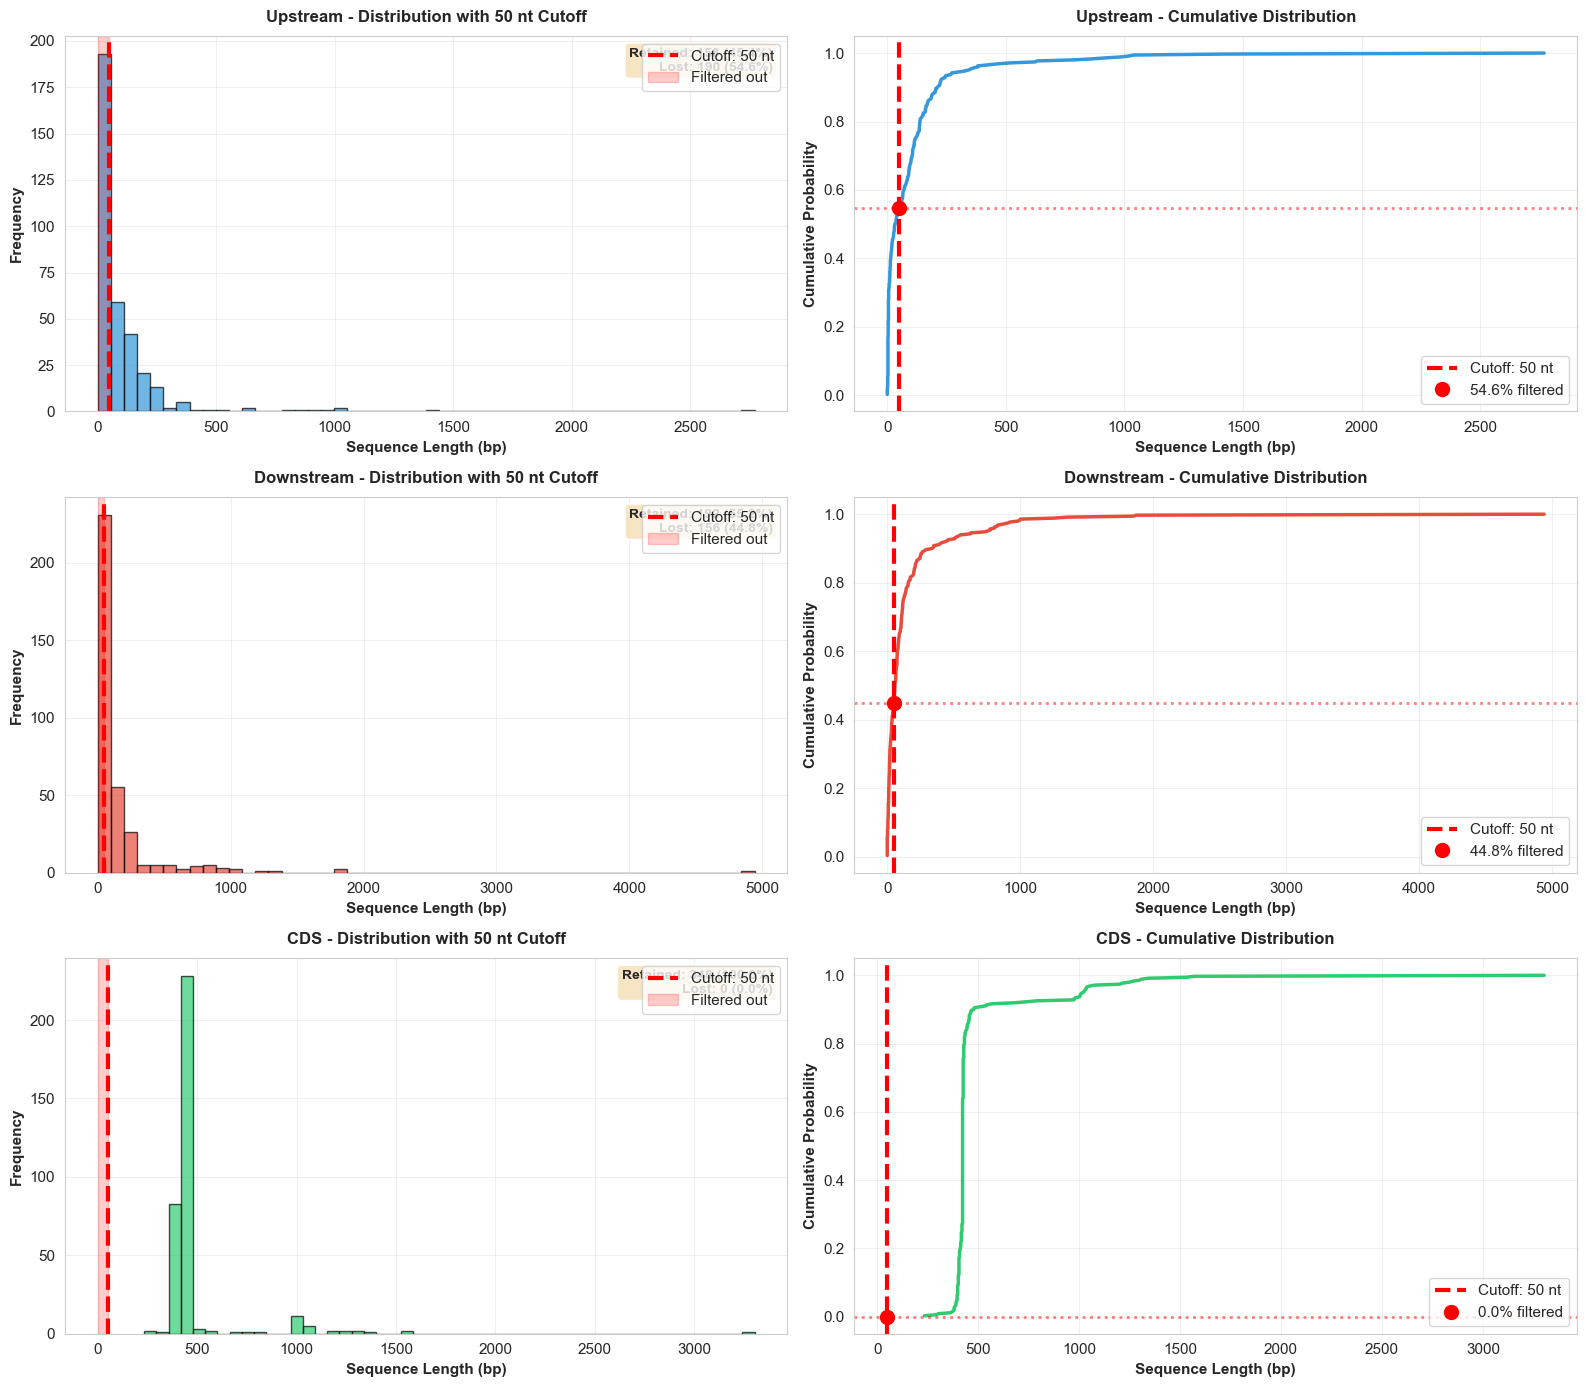

In [18]:
# Create comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

datasets = [
    (upstream_lengths, 'Upstream', '#3498db'),
    (downstream_lengths, 'Downstream', '#e74c3c'),
    (cds_lengths, 'CDS', '#2ecc71')
]

for idx, (data, title, color) in enumerate(datasets):
    # Histogram with cutoff line
    ax1 = axes[idx, 0]
    ax1.hist(data, bins=50, alpha=0.7, color=color, edgecolor='black')
    ax1.axvline(TARGET_CUTOFF, color='red', linestyle='--', linewidth=3, 
                label=f'Cutoff: {TARGET_CUTOFF} nt')
    
    # Shade the region that would be filtered out
    ax1.axvspan(0, TARGET_CUTOFF, alpha=0.2, color='red', label='Filtered out')
    
    retained_count = sum(1 for l in data if l >= TARGET_CUTOFF)
    lost_count = len(data) - retained_count
    
    ax1.set_xlabel('Sequence Length (bp)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title(f'{title} - Distribution with {TARGET_CUTOFF} nt Cutoff', 
                  fontsize=12, fontweight='bold', pad=10)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Add text box with statistics
    stats_text = f"Retained: {retained_count:,} ({retained_count/len(data)*100:.1f}%)\n"
    stats_text += f"Lost: {lost_count:,} ({lost_count/len(data)*100:.1f}%)"
    ax1.text(0.98, 0.97, stats_text, transform=ax1.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10, fontweight='bold')
    
    # Cumulative distribution with cutoff
    ax2 = axes[idx, 1]
    sorted_data = np.sort(data)
    y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax2.plot(sorted_data, y, linewidth=2.5, color=color)
    ax2.axvline(TARGET_CUTOFF, color='red', linestyle='--', linewidth=3,
                label=f'Cutoff: {TARGET_CUTOFF} nt')
    
    # Find the y-value at the cutoff
    cutoff_y = sum(1 for l in data if l < TARGET_CUTOFF) / len(data)
    ax2.axhline(cutoff_y, color='red', linestyle=':', linewidth=2, alpha=0.5)
    ax2.plot(TARGET_CUTOFF, cutoff_y, 'ro', markersize=10, 
             label=f'{cutoff_y*100:.1f}% filtered')
    
    ax2.set_xlabel('Sequence Length (bp)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
    ax2.set_title(f'{title} - Cumulative Distribution', 
                  fontsize=12, fontweight='bold', pad=10)
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Interactive Cutoff Explorer

Test any cutoff value you want to see the impact.

In [19]:
def explore_cutoff(cutoff_value):
    """
    Interactively explore the impact of any cutoff value.
    """
    print(f"\n{'='*80}")
    print(f"CUTOFF ANALYSIS: {cutoff_value} nt")
    print(f"{'='*80}\n")
    
    total_before = len(upstream_lengths) + len(downstream_lengths) + len(cds_lengths)
    total_after = 0
    total_lost = 0
    
    results = []
    
    for region_name, lengths in regions:
        total = len(lengths)
        retained = sum(1 for l in lengths if l >= cutoff_value)
        lost = total - retained
        total_after += retained
        total_lost += lost
        
        results.append({
            'Region': region_name,
            'Total': total,
            'Retained': retained,
            'Lost': lost,
            'Retained_%': (retained / total * 100) if total > 0 else 0,
            'Lost_%': (lost / total * 100) if total > 0 else 0
        })
        
        print(f"{region_name}:")
        print(f"  Retained: {retained:,} / {total:,} ({retained/total*100:.2f}%)")
        print(f"  Lost: {lost:,} ({lost/total*100:.2f}%)\n")
    
    print(f"{'='*80}")
    print(f"TOTAL ACROSS ALL REGIONS:")
    print(f"  Before filtering: {total_before:,} sequences")
    print(f"  After filtering: {total_after:,} sequences ({total_after/total_before*100:.2f}%)")
    print(f"  Lost: {total_lost:,} sequences ({total_lost/total_before*100:.2f}%)")
    print(f"{'='*80}\n")
    
    df = pd.DataFrame(results).round(2)
    display(df)
    
    return df

# Try your target cutoff
result_50 = explore_cutoff(50)

# Try other values if you want
print("\n\nTo test other cutoffs, run: explore_cutoff(YOUR_VALUE)")
print("For example: explore_cutoff(75) or explore_cutoff(100)")


CUTOFF ANALYSIS: 50 nt

Upstream:
  Retained: 158 / 348 (45.40%)
  Lost: 190 (54.60%)

Downstream:
  Retained: 192 / 348 (55.17%)
  Lost: 156 (44.83%)

CDS:
  Retained: 348 / 348 (100.00%)
  Lost: 0 (0.00%)

TOTAL ACROSS ALL REGIONS:
  Before filtering: 1,044 sequences
  After filtering: 698 sequences (66.86%)
  Lost: 346 sequences (33.14%)



,Region,Total,Retained,Lost,Retained_%,Lost_%
0,Upstream,348,158,190,45.40,54.60
1,Downstream,348,192,156,55.17,44.83
2,CDS,348,348,0,100.00,0.00




To test other cutoffs, run: explore_cutoff(YOUR_VALUE)
For example: explore_cutoff(75) or explore_cutoff(100)


## 6. Cutoff Comparison Visualization

Compare the effect of multiple cutoffs side-by-side.

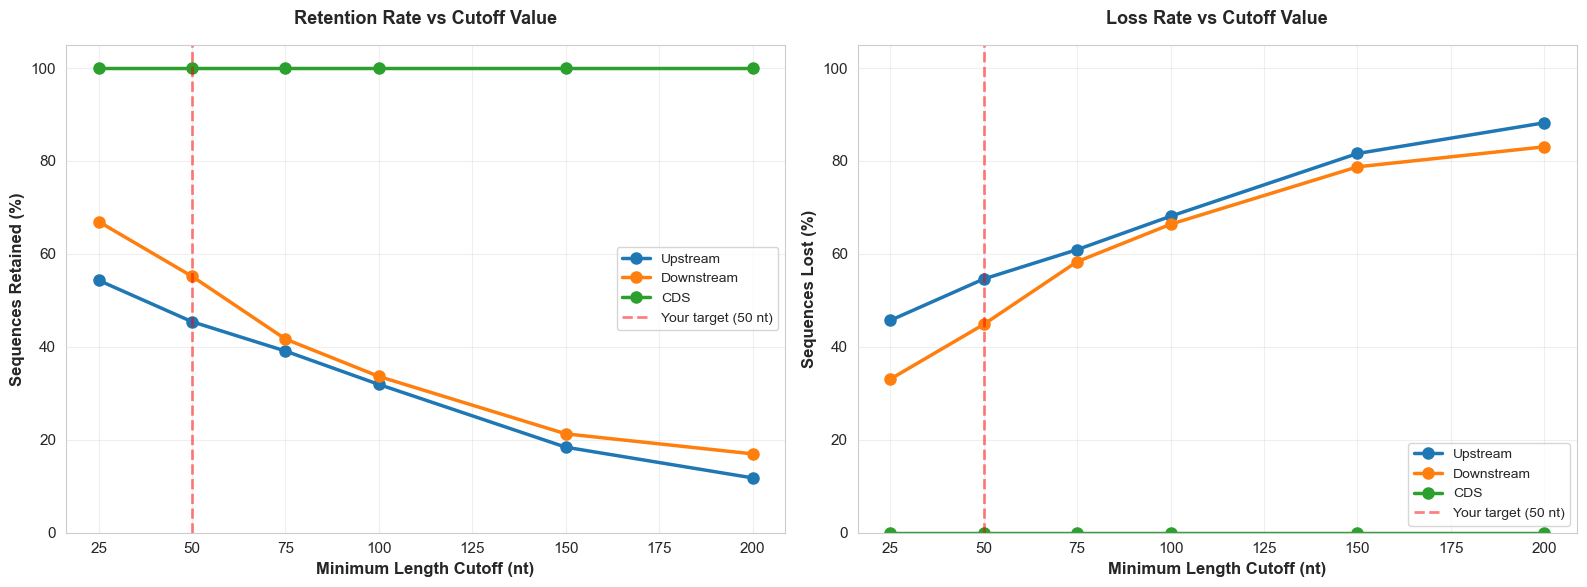


Detailed Comparison Table:


Region,CDS,Downstream,Upstream
Cutoff,,,
25,100.0,66.95,54.31
50,100.0,55.17,45.40
75,100.0,41.67,39.08
100,100.0,33.62,31.90
150,100.0,21.26,18.39
200,100.0,16.95,11.78


In [20]:
# Compare multiple cutoffs
cutoff_values = [25, 50, 75, 100, 150, 200]
comparison_data = []

for cutoff in cutoff_values:
    for region_name, lengths in regions:
        total = len(lengths)
        retained = sum(1 for l in lengths if l >= cutoff)
        
        comparison_data.append({
            'Cutoff': cutoff,
            'Region': region_name,
            'Retained_%': (retained / total * 100) if total > 0 else 0,
            'Lost_%': ((total - retained) / total * 100) if total > 0 else 0
        })

comparison_df = pd.DataFrame(comparison_data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Retention rates
ax1 = axes[0]
for region_name in ['Upstream', 'Downstream', 'CDS']:
    region_data = comparison_df[comparison_df['Region'] == region_name]
    ax1.plot(region_data['Cutoff'], region_data['Retained_%'], 
             marker='o', linewidth=2.5, markersize=8, label=region_name)

ax1.axvline(50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Your target (50 nt)')
ax1.set_xlabel('Minimum Length Cutoff (nt)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sequences Retained (%)', fontsize=12, fontweight='bold')
ax1.set_title('Retention Rate vs Cutoff Value', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 105])

# Loss rates
ax2 = axes[1]
for region_name in ['Upstream', 'Downstream', 'CDS']:
    region_data = comparison_df[comparison_df['Region'] == region_name]
    ax2.plot(region_data['Cutoff'], region_data['Lost_%'], 
             marker='o', linewidth=2.5, markersize=8, label=region_name)

ax2.axvline(50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Your target (50 nt)')
ax2.set_xlabel('Minimum Length Cutoff (nt)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sequences Lost (%)', fontsize=12, fontweight='bold')
ax2.set_title('Loss Rate vs Cutoff Value', fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

print("\nDetailed Comparison Table:")
print("="*80)
pivot_retained = comparison_df.pivot(index='Cutoff', columns='Region', values='Retained_%').round(2)
display(pivot_retained)

## 7. Sequences Below Cutoff - Detailed Look

What are we actually filtering out?

SEQUENCES BELOW 50 nt - DETAILED ANALYSIS

UPSTREAM:
  Count: 190
  Mean length: 11.5 nt
  Median length: 5.0 nt
  Range: 0-49 nt
  Std dev: 12.0 nt

  Distribution by length bin:
    0-10 nt: 113 sequences (59.5%)
    11-20 nt: 36 sequences (18.9%)
    21-30 nt: 16 sequences (8.4%)
    31-40 nt: 11 sequences (5.8%)
    41-50 nt: 8 sequences (4.2%)

DOWNSTREAM:
  Count: 156
  Mean length: 16.8 nt
  Median length: 14.0 nt
  Range: 0-49 nt
  Std dev: 13.5 nt

  Distribution by length bin:
    0-10 nt: 40 sequences (25.6%)
    11-20 nt: 50 sequences (32.1%)
    21-30 nt: 15 sequences (9.6%)
    31-40 nt: 20 sequences (12.8%)
    41-50 nt: 12 sequences (7.7%)

CDS: No sequences below 50 nt


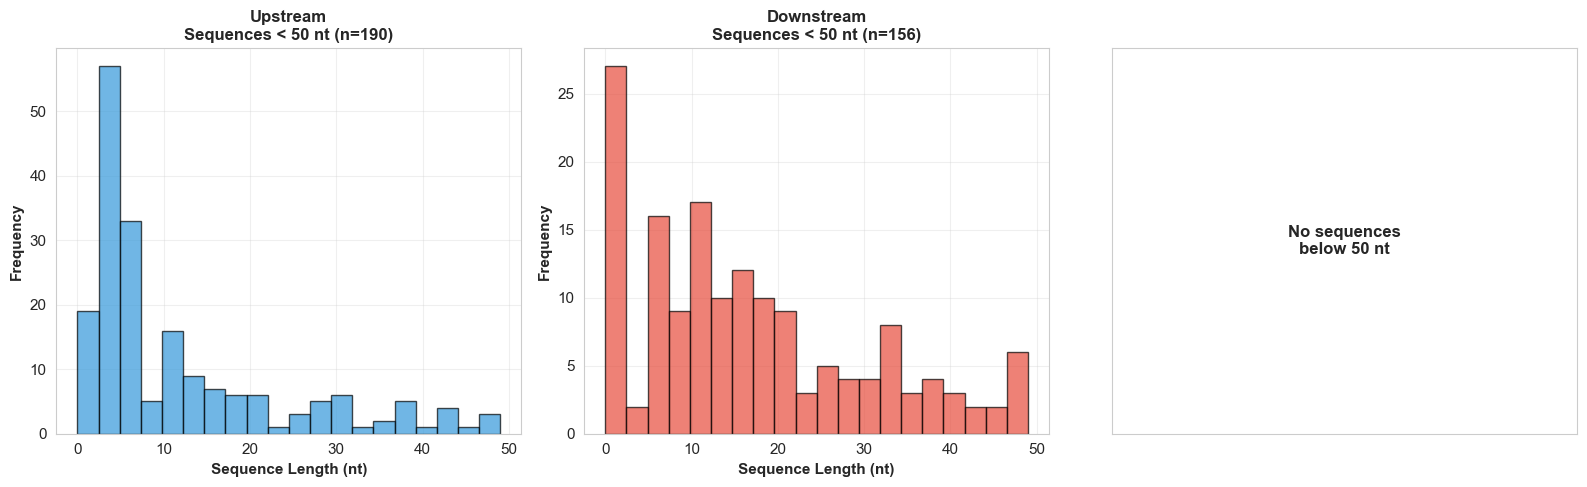

In [21]:
TARGET_CUTOFF = 50

print(f"SEQUENCES BELOW {TARGET_CUTOFF} nt - DETAILED ANALYSIS")
print("="*80)

for region_name, lengths in regions:
    below_cutoff = [l for l in lengths if l < TARGET_CUTOFF]
    
    if below_cutoff:
        print(f"\n{region_name.upper()}:")
        print(f"  Count: {len(below_cutoff)}")
        print(f"  Mean length: {np.mean(below_cutoff):.1f} nt")
        print(f"  Median length: {np.median(below_cutoff):.1f} nt")
        print(f"  Range: {min(below_cutoff)}-{max(below_cutoff)} nt")
        print(f"  Std dev: {np.std(below_cutoff):.1f} nt")
        
        # Length bins
        bins = [0, 10, 20, 30, 40, TARGET_CUTOFF]
        bin_labels = ['0-10', '11-20', '21-30', '31-40', f'41-{TARGET_CUTOFF}']
        
        print(f"\n  Distribution by length bin:")
        for i in range(len(bins)-1):
            count = sum(1 for l in below_cutoff if bins[i] < l <= bins[i+1])
            if count > 0:
                print(f"    {bin_labels[i]} nt: {count} sequences ({count/len(below_cutoff)*100:.1f}%)")
    else:
        print(f"\n{region_name.upper()}: No sequences below {TARGET_CUTOFF} nt")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (region_name, lengths, color) in enumerate(zip(
    ['Upstream', 'Downstream', 'CDS'],
    [upstream_lengths, downstream_lengths, cds_lengths],
    ['#3498db', '#e74c3c', '#2ecc71']
)):
    ax = axes[idx]
    below = [l for l in lengths if l < TARGET_CUTOFF]
    
    if below:
        ax.hist(below, bins=20, color=color, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Sequence Length (nt)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax.set_title(f'{region_name}\nSequences < {TARGET_CUTOFF} nt (n={len(below)})',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No sequences\nbelow {TARGET_CUTOFF} nt',
               ha='center', va='center', fontsize=12, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Export Filtered Sequences (Optional)

If you want to create new FASTA files with sequences ≥ cutoff.

In [22]:
def filter_fasta_by_length(input_file, output_file, min_length):
    """
    Create a new FASTA file containing only sequences >= min_length.
    
    Parameters:
    -----------
    input_file : str
        Path to input FASTA file
    output_file : str
        Path to output FASTA file
    min_length : int
        Minimum sequence length to retain
    
    Returns:
    --------
    tuple : (retained_count, filtered_count)
    """
    retained = []
    filtered = 0
    
    with open(input_file, 'r') as handle:
        for record in SeqIO.parse(handle, 'fasta'):
            if len(record.seq) >= min_length:
                retained.append(record)
            else:
                filtered += 1
    
    # Write filtered sequences
    with open(output_file, 'w') as out_handle:
        SeqIO.write(retained, out_handle, 'fasta')
    
    return len(retained), filtered

# Example usage - uncomment to run
MIN_LENGTH = 50

# filter_fasta_by_length(upstream_file, f"upstream_filtered_{MIN_LENGTH}nt.fasta", MIN_LENGTH)
# filter_fasta_by_length(downstream_file, f"downstream_filtered_{MIN_LENGTH}nt.fasta", MIN_LENGTH)
# filter_fasta_by_length(cds_file, f"cds_filtered_{MIN_LENGTH}nt.fasta", MIN_LENGTH)

print(f"To create filtered FASTA files with sequences ≥ {MIN_LENGTH} nt:")
print("Uncomment the three lines above and run this cell.")
print(f"\nThis will create:")
print(f"  - upstream_filtered_{MIN_LENGTH}nt.fasta")
print(f"  - downstream_filtered_{MIN_LENGTH}nt.fasta")
print(f"  - cds_filtered_{MIN_LENGTH}nt.fasta")

To create filtered FASTA files with sequences ≥ 50 nt:
Uncomment the three lines above and run this cell.

This will create:
  - upstream_filtered_50nt.fasta
  - downstream_filtered_50nt.fasta
  - cds_filtered_50nt.fasta


## Summary & Recommendations

Based on the analysis above, you can see:
- Exact number and percentage of sequences that would be filtered at 50 nt
- How the distribution changes before/after filtering
- What sequences you're actually losing (their length distribution)
- Comparison with other potential cutoff values

**Key considerations for choosing a cutoff:**
- What percentage of data loss is acceptable?
- Are the very short sequences likely to be biological or artifacts?
- Does the cutoff preserve enough data for meaningful analysis?
- Do different regions (upstream/downstream/CDS) need different cutoffs?